In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from IPython.core.pylabtools import figsize

from func.UsefulFunctions import *
import seaborn as sns

In [2]:
def replaceToNulls(df, column):
    columnLabel = column + "Label"
    noLabel = df[df[column].isin(df[columnLabel])][columnLabel]
    noLabel = noLabel.to_list()
    noNameDict = {k: "null/unknown" for k in noLabel}
    df[columnLabel] = df[columnLabel].replace(noNameDict)

    df[column] = df[column].where(df[column].str.startswith("Q"), None)
    return df

In [3]:
genreDF = pd.read_csv("./Data/Query 121 - Genres and their parent genres and inception date.csv")
genreDF[['genre','parentGenre']] = genreDF[['genre','parentGenre']].map(getEntityIDValue)

genreDF = replaceToNulls(genreDF, 'parentGenre')
genreDF = replaceToNulls(genreDF, 'genre')

genreGraph = addToNetwork4(genreDF, "parentGenre", "genre", "has child genre","Genre","Genre","parentGenreLabel","genreLabel")



In [4]:
#How many genres are there
len(genreDF["genre"].dropna().drop_duplicates())

6307

In [5]:
genreGraph.nodes["Q104695865"]

{'EntityType': 'Genre', 'Label': 'hyperpop'}

In [6]:
nx.write_graphml(genreGraph, "./graphs/genreGraph.graphml",encoding="utf-8")

In [7]:
#Show the network is scale-free
nodeDegree = genreGraph.degree()

nodeDegreeDF = pd.DataFrame(nodeDegree, columns=["node", "degree"])

In [8]:
nodeDegreeDF.head()

,node,degree
0,Q1074080,16
1,Q623824,3
2,Q2742742,4
3,Q623904,5
4,Q11400811,21


<Axes: title={'center': 'Degree Distribution of Genre Network'}, xlabel='degree', ylabel='Node Count'>

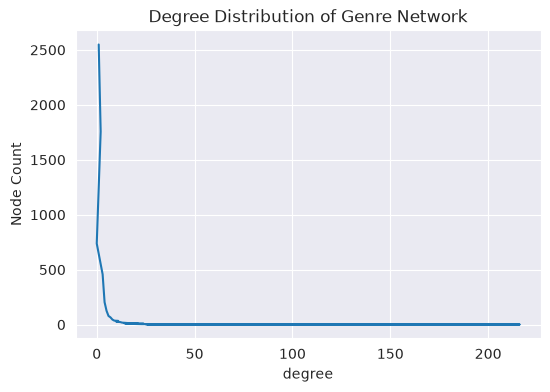

In [9]:
 #Draw a scatter plot of the node data

degreeValueCount = nodeDegreeDF["degree"].value_counts()
degreeValueCount.plot(kind="line", ylabel="Node Count", title="Degree Distribution of Genre Network", figsize=(6,4))

In [10]:
#These genres of Low connectivity what countries are they from



In [11]:
#Let's calculate some statistics

###Modularity
###Centrality measures

###Degree centrality


###betweenness centrality

Get the genres with their wikipedia pages

In [12]:
genreWiki = pd.read_csv("./Data/Query 19 - Genres on wikidata and their wikipedia pages.csv")

genreWiki["genre"] = genreWiki["genre"].map(getEntityIDValue)
genreWiki = replaceToNulls(genreWiki, 'genre')
display(genreWiki[~genreWiki.article.str.contains("en.wikipedia", case=False)])
#There are only valid wikipedia links in there

genresAndTheirWiki = genreDF.merge(genreWiki[["genre",'page_titleEN',"article"]], on="genre", how="left")
genresAndTheirWiki.head()

,genre,genreLabel,page_titleEN,article


,genre,genreLabel,parentGenre,parentGenreLabel,inception,Type,page_titleEN,article
0,Q623824,arabesque,Q1074080,music of Turkey,NaN,has child genre,Arabesque (Turkish music),https://en.wikipedia.org/wiki/Arabesque_(Turki...
1,Q623904,Andalusi classical music,Q2742742,music of Andalusia,1000-01-01T00:00:00Z,has child genre,Andalusi classical music,https://en.wikipedia.org/wiki/Andalusi_classic...
2,Q623904,Andalusi classical music,Q11400811,music of North Africa,1000-01-01T00:00:00Z,has child genre,Andalusi classical music,https://en.wikipedia.org/wiki/Andalusi_classic...
3,Q623904,Andalusi classical music,Q107189715,Arabic classical music,1000-01-01T00:00:00Z,has child genre,Andalusi classical music,https://en.wikipedia.org/wiki/Andalusi_classic...
4,Q624044,Arabic music,Q1503406,music of the Middle East,NaN,has child genre,Arabic music,https://en.wikipedia.org/wiki/Arabic_music


In [13]:
noWiki = genresAndTheirWiki[genresAndTheirWiki.article.isnull()]["genre"].dropna().drop_duplicates()
hasWiki = genresAndTheirWiki[~genresAndTheirWiki.article.isnull()]["genre"].dropna().drop_duplicates()

In [14]:
print(f"There {len(hasWiki)} genres with a Wikipedia page")
print(f"There {len(noWiki)} genres do not have a Wikipedia page")

There 3329 genres with a Wikipedia page
There 2978 genres do not have a Wikipedia page


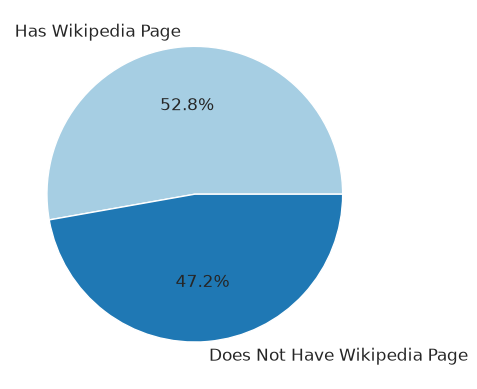

In [15]:
plt.rc('font', size=12)
makePieChart(["Has Wikipedia Page", "Does Not Have Wikipedia Page"], [len(hasWiki), len(noWiki)], "Genres On Wikidata and Their Wikipedia Presence", "Paired" )

In [16]:
#What is the most well described audio genre
genreStatements = pd.read_csv("./Data/Qeury 28 - Genres and number of statements.csv")
genreStatements.genre = genreStatements.genre.map(getEntityIDValue)
genresAndTheirWiki = genresAndTheirWiki.merge(genreStatements, on="genre", how="left")
genresAndTheirWiki = genresAndTheirWiki.sort_values(by=["statementCount"], ascending=False)

genreArticleStatementCount = genresAndTheirWiki[["genre", "genreLabel", "article", "statementCount", "page_titleEN"]].drop_duplicates()
genreArticleStatementCount.head()

,genre,genreLabel,article,statementCount,page_titleEN
6334,Q1344,opera,https://en.wikipedia.org/wiki/Opera,160,Opera
6343,Q8341,jazz,https://en.wikipedia.org/wiki/Jazz,154,Jazz
6360,Q11399,rock music,https://en.wikipedia.org/wiki/Rock_music,106,Rock music
6348,Q9759,blues,https://en.wikipedia.org/wiki/Blues,104,Blues
193,Q83440,country music,https://en.wikipedia.org/wiki/Country_music,102,Country music


In [17]:
def createBoxPlot(listOfvalues):
    fig, ax = plt.subplots()
    ax.boxplot(listOfvalues)
    plt.show()

In [18]:
def createViolinPlot(listOfValues):
    sns.violinplot(listOfValues)

def createViolinPlotDF(df):
    ax = sns.violinplot(df)
    #ax.set_xticklabels(["Wikidata", "Wikipedia"])
    ax.set_ylabel("Statement Count")



,Wikidata,Wikipedia
0,160,160.0
1,154,154.0
2,106,106.0
3,104,104.0
4,102,102.0


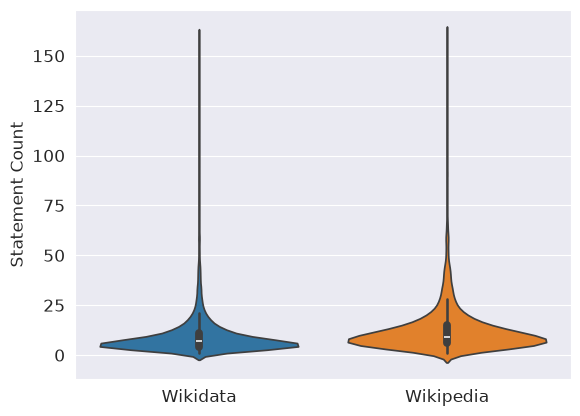

In [19]:
wikiDataStatements = genreArticleStatementCount["statementCount"].to_list()
wikipediaStatements = genreArticleStatementCount[~genreArticleStatementCount["article"].isnull()]["statementCount"].to_list()

wikidataSeries = pd.Series(wikiDataStatements)
wikipediaSeries = pd.Series(wikipediaStatements)
plotDF = pd.concat([wikidataSeries, wikipediaSeries], axis=1, ignore_index=True)
plotDF = plotDF.rename(columns={0:"Wikidata",1:"Wikipedia"})
display(plotDF.head())
#plotDF = pd.DataFrame({"Wikidata": wikiDataStatements, "Wikipedia": wikipediaStatements})
#createBoxPlot([wikiDataStatements, wikipediaStatements])
plt.rc('font', size=12)
createViolinPlotDF(plotDF)

In [20]:
genreArticleStatementCount.head()

,genre,genreLabel,article,statementCount,page_titleEN
6334,Q1344,opera,https://en.wikipedia.org/wiki/Opera,160,Opera
6343,Q8341,jazz,https://en.wikipedia.org/wiki/Jazz,154,Jazz
6360,Q11399,rock music,https://en.wikipedia.org/wiki/Rock_music,106,Rock music
6348,Q9759,blues,https://en.wikipedia.org/wiki/Blues,104,Blues
193,Q83440,country music,https://en.wikipedia.org/wiki/Country_music,102,Country music


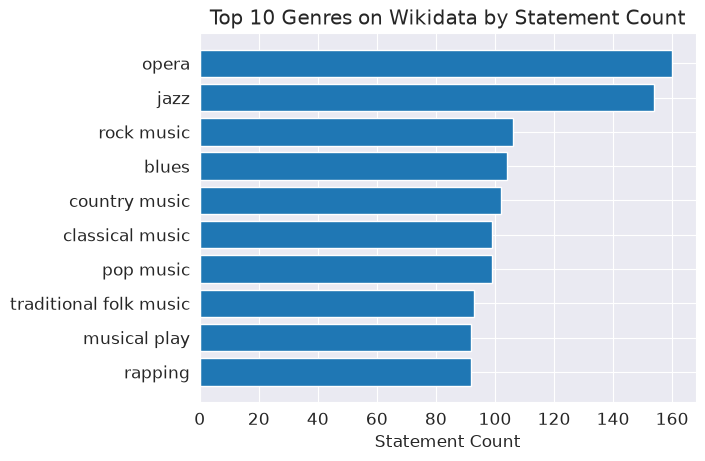

In [21]:
top10Wikidata = genreArticleStatementCount[["genre","genreLabel", "statementCount"]].sort_values(by="statementCount", ascending=False)[0:10]
plt.rc('font', size=12)
horizontalBarChart(top10Wikidata["genreLabel"].to_list(), top10Wikidata["statementCount"].to_list(),"Top 10 Genres on Wikidata by Statement Count", "Statement Count")

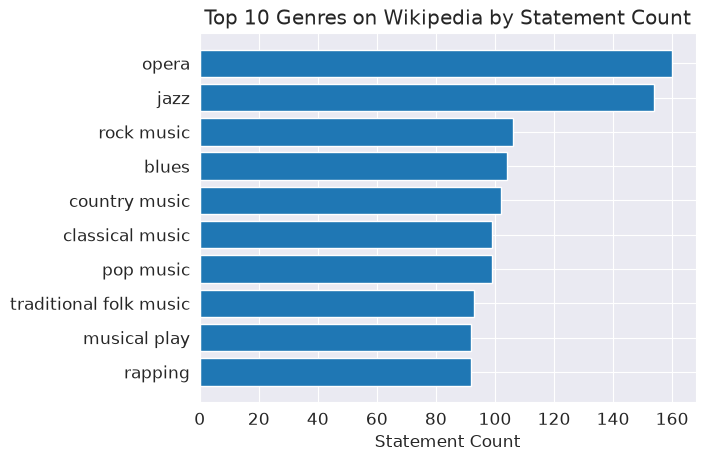

In [22]:
top10Wikipedia = genreArticleStatementCount[~genreArticleStatementCount["article"].isnull()][["genre","genreLabel", "statementCount"]].sort_values(by="statementCount", ascending=False)[0:10]
plt.rc('font', size=12)
horizontalBarChart(top10Wikipedia["genreLabel"].to_list(), top10Wikipedia["statementCount"].to_list(),"Top 10 Genres on Wikipedia by Statement Count", "Statement Count")

In [23]:
with open("./Find_The_Music_Files/List_of_articles_with_the_sound_files.txt") as f:
    genreFile = f.readlines()

genreDict = {k.split(",")[0]:len(list(filter(lambda x : x != "none", k.strip("\n").split(",")[1:]))) for k in genreFile}

genreMedia = pd.DataFrame(genreDict.items(), columns=["genreCapitalised", "numberOfMedia"])
genreMedia.head()




,genreCapitalised,numberOfMedia
0,POLYPHONY,1
1,GOTHIC METAL,4
2,OPERA,9
3,PUNK ROCK,2
4,MUSICAL THEATRE,0


In [24]:
#statementCount and media

genreArticleStatementCount.head()

genreMediaCount = genreArticleStatementCount[["genre","genreLabel", "statementCount", "page_titleEN"]]
genreMediaCount["page_titleEN"] = genreMediaCount["page_titleEN"].str.upper()


genreMediaCount = genreMediaCount.merge(genreMedia, left_on="page_titleEN", right_on="genreCapitalised", how="left")
genreMediaCount.drop_duplicates(inplace=True)
genreMediaCount.dropna(inplace=True)
display(genreMediaCount.head())
genreMediaCount.dtypes

,genre,genreLabel,statementCount,page_titleEN,genreCapitalised,numberOfMedia
0,Q1344,opera,160,OPERA,OPERA,9.0
1,Q8341,jazz,154,JAZZ,JAZZ,10.0
2,Q11399,rock music,106,ROCK MUSIC,ROCK MUSIC,0.0
3,Q9759,blues,104,BLUES,BLUES,3.0
4,Q83440,country music,102,COUNTRY MUSIC,COUNTRY MUSIC,0.0


genre                   str
genreLabel              str
statementCount        int64
page_titleEN            str
genreCapitalised        str
numberOfMedia       float64
dtype: object

Text(0, 0.5, 'Number of Media in Log Scale')

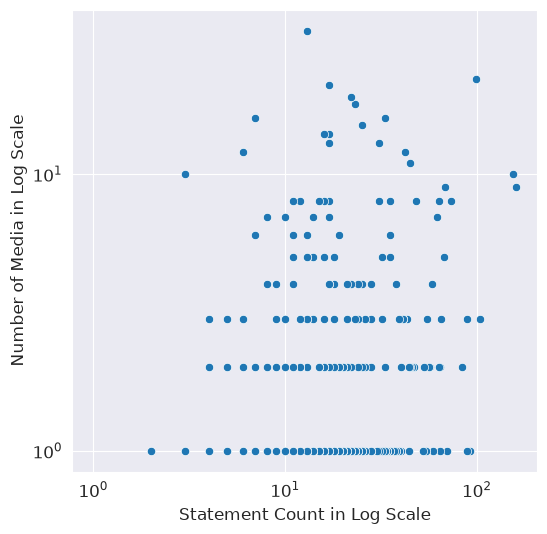

In [25]:
#scatter plot
plt.figure(figsize(6,6))
ax = sns.scatterplot(genreMediaCount, x= "statementCount", y="numberOfMedia")
ticks= range(0, max(genreMediaCount["statementCount"]), 10)
ax.set_xticks(ticks)
ax.set_xscale("log")
ax.set_xlabel("Statement Count in Log Scale")
ax.set_yscale("log")
ax.set_ylabel("Number of Media in Log Scale")

,genre,article,statementCount
6334,1344,True,160
6337,2743,True,92
6338,3071,True,84
6339,3858,True,17
6340,4797,True,29


,genre,article,statementCount
8622,140377109,False,6
6873,140389135,False,4
6875,140428185,False,5
6876,140451598,False,3
6878,140463448,False,4


genre             float64
article              bool
statementCount      int64
dtype: object


Text(0, 0.5, 'Density of Genres Created')

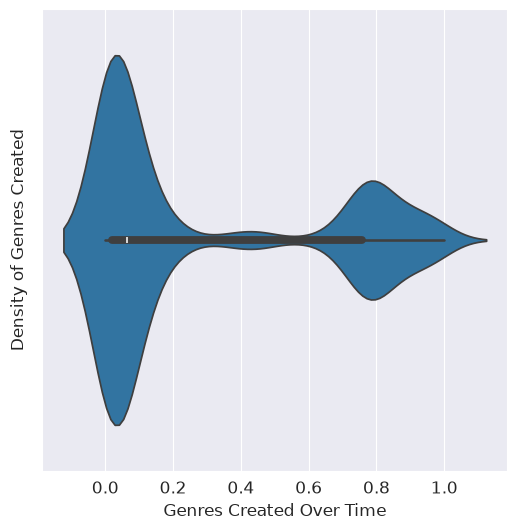

In [26]:
#Looking at the creation of genres
plt.rc('font', size=12)
genreCreation = genreArticleStatementCount[["genre", "article", "statementCount"]]
genreCreation.genre = genreCreation.genre.str.strip("Q")
genreCreation.article = ~genreCreation.article.isnull()
genreCreation.genre = pd.to_numeric(genreCreation.genre, errors="coerce")
genreCreation = genreCreation.sort_values(by=["genre"], ascending=True)
display(genreCreation.head())
display(genreCreation.tail())
genreCreationPreNorm = genreCreation.copy()
genreCreation.genre = (genreCreation.genre- genreCreation.genre.min())/(genreCreation.genre.max() - genreCreation.genre.min())
print(genreCreation.dtypes)
ax= sns.violinplot(genreCreation, x="genre")
ax.set_xlabel("Genres Created Over Time")
ax.set_ylabel("Density of Genres Created")



<Axes: xlabel='genre'>

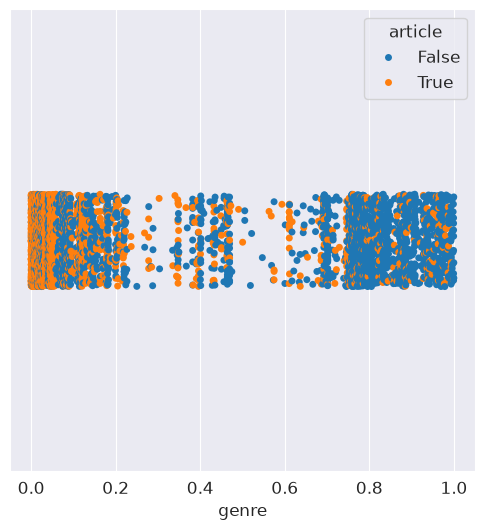

In [27]:
#What is the first genre
sns.stripplot(genreCreation, x="genre", hue="article")

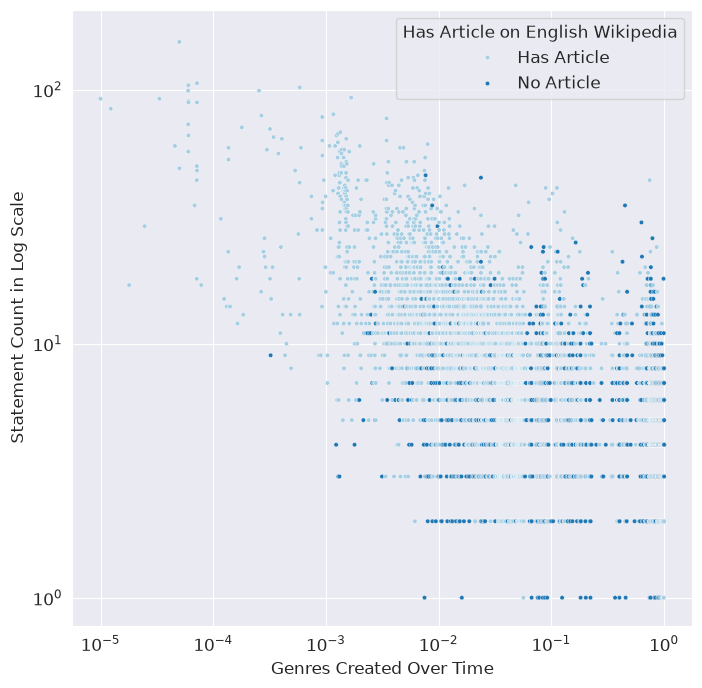

In [28]:
plt.figure(figsize(8,8))
genreCreation.article = genreCreation.article.replace({True:"Has Article", False:"No Article"})
plt.rc('font', size=12)
ax1 = sns.scatterplot(genreCreation, x="genre", y="statementCount", hue="article", s=10, palette="Paired")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Genres Created Over Time")
ax1.set_ylabel("Statement Count in Log Scale")
ax1.legend(title = "Has Article on English Wikipedia")
